# 04: Spatial Data & Census Boundaries

This notebook demonstrates the spatial data capabilities of siege_utilities, including:

1. **Census Boundary Downloads** - Download TIGER/Line shapefiles
2. **State FIPS Normalization** - Convert between state names, abbreviations, and FIPS codes
3. **Geographic Level Discovery** - Find available boundary types for any year
4. **Working with GeoDataFrames** - Basic spatial operations

## Prerequisites

```bash
pip install -e /path/to/siege_utilities
```

In [1]:
import siege_utilities as su

# Initialize logging
su.configure_shared_logging(level="INFO")

[siege_utilities] 2026-02-21 18:37:28,124 WARNING: Could not create directory /Users/dheerajchand/Documents/Professional/Siege_Analytics/Code/siege_utilities/data: [Errno 13] Permission denied: '/Users'


[siege_utilities] 2026-02-21 18:37:28,125 WARNING: Could not create directory /Users/dheerajchand/Documents/Professional/Siege_Analytics/Code/siege_utilities/data/census: [Errno 13] Permission denied: '/Users'


[siege_utilities] 2026-02-21 18:37:28,126 WARNING: Could not create directory /Users/dheerajchand/Documents/Professional/Siege_Analytics/Code/siege_utilities/data/nces: [Errno 13] Permission denied: '/Users'


[siege_utilities] 2026-02-21 18:37:28,126 WARNING: Could not create directory /Users/dheerajchand/Documents/Professional/Siege_Analytics/Code/siege_utilities/data/samples: [Errno 13] Permission denied: '/Users'


[siege_utilities] 2026-02-21 18:37:28,411 INFO: Importing spark_utils from siege_utilities.distributed.spark_utils


...

[siege_utilities] 2026-02-21 18:37:33,457 INFO: Registered chart type: comparison_chart


[siege_utilities] 2026-02-21 18:37:33,458 INFO: Importing environment from siege_utilities.testing.environment


[siege_utilities] 2026-02-21 18:37:33,459 INFO: Successfully imported 11 functions from environment


[siege_utilities] 2026-02-21 18:37:33,460 INFO: Importing runner from siege_utilities.testing.runner


[siege_utilities] 2026-02-21 18:37:33,461 INFO: Successfully imported 11 functions from runner


In [2]:
%matplotlib inline

# Imports
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from siege_utilities.geo.spatial_data import (
    # Census data functions
    get_census_boundaries,
    download_data,
    get_available_years,
    get_year_directory_contents,
    discover_boundary_types,
    
    # Reference data
    BOUNDARY_TYPE_CATALOG,
    
    # State normalization
    normalize_state_identifier,
    get_state_by_abbreviation,
    get_state_by_name,
    
    # Global instances
    census_source
)

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

su.log_info("Imports successful!")

# --- Output configuration ---
OUTPUT_DIR = Path("output") / "notebook_04"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

su.log_info(f"Output directory: {OUTPUT_DIR}  (exists={OUTPUT_DIR.exists()})")

[siege_utilities] 2026-02-21 18:37:33,475 INFO: Imports successful!


[siege_utilities] 2026-02-21 18:37:33,475 INFO: Output directory: output/notebook_04  (exists=True)


In [3]:
# Retrieve Census API key: try 1Password first, fall back to env var
from siege_utilities.config.credential_manager import get_credential
import os

_key_source = None
census_api_key = get_credential(
    service='Census API Credentials',
    username='api',
    field='credential',
    vault='Employee',
    account='Siege_Analytics'
)
if census_api_key:
    _key_source = '1Password (Employee/Census API Credentials)'
else:
    census_api_key = os.environ.get('CENSUS_API_KEY')
    if census_api_key:
        _key_source = 'environment variable (CENSUS_API_KEY)'

if census_api_key:
    os.environ['CENSUS_API_KEY'] = census_api_key
    su.log_info(f"Census API key loaded from {_key_source}")
else:
    su.log_warning("Census API key not found — set CENSUS_API_KEY env var or sign into 1Password")

[siege_utilities] 2026-02-21 18:37:33,493 INFO: Available credential backends: ['files', 'env', 'prompt', '1password']


[siege_utilities] 2026-02-21 18:37:33,494 INFO: Credential manager initialized with backends: {'files': True, 'env': True, 'prompt': True, '1password': True, 'keychain': False}


[siege_utilities] 2026-02-21 18:37:33,495 INFO: Credential search paths: [PosixPath('/home/dheerajchand/git/siege-analytics/siege_utilities/notebooks/credentials'), PosixPath('/home/dheerajchand/.siege_utilities/credentials')]


[siege_utilities] 2026-02-21 18:37:33,567 WARNING: Could not retrieve credential for Census API Credentials from any backend


[siege_utilities] 2026-02-21 18:37:33,568 WARNING: Census API key not found — set CENSUS_API_KEY env var or sign into 1Password


## 1. State FIPS Normalization

The `normalize_state_identifier()` function accepts any state format and returns the FIPS code.

In [4]:
# Test various input formats
test_inputs = [
    '06',           # FIPS code
    'CA',           # Abbreviation
    'California',   # Full name
    'california',   # Lowercase
    'CALIFORNIA',   # Uppercase
    'TX',
    'New York',
    'ny',
]

su.log_info("State FIPS Normalization")
su.log_info("=" * 40)
for inp in test_inputs:
    fips = normalize_state_identifier(inp)
    su.log_info(f"{inp:15} -> {fips}")

[siege_utilities] 2026-02-21 18:37:33,576 INFO: State FIPS Normalization


[siege_utilities] 2026-02-21 18:37:33,576 INFO: ========================================


[siege_utilities] 2026-02-21 18:37:33,577 INFO: 06              -> 06


[siege_utilities] 2026-02-21 18:37:33,577 INFO: CA              -> 06


[siege_utilities] 2026-02-21 18:37:33,577 INFO: California      -> 06


[siege_utilities] 2026-02-21 18:37:33,578 INFO: california      -> 06


[siege_utilities] 2026-02-21 18:37:33,579 INFO: CALIFORNIA      -> 06


[siege_utilities] 2026-02-21 18:37:33,579 INFO: TX              -> 48


[siege_utilities] 2026-02-21 18:37:33,579 INFO: New York        -> 36


[siege_utilities] 2026-02-21 18:37:33,580 INFO: ny              -> 36


In [5]:
# Get full state info
ca_info = get_state_by_abbreviation('CA')
su.log_info("State info for CA:")
su.log_info(str(ca_info))

su.log_info("")
tx_info = get_state_by_name('Texas')
su.log_info("State info for Texas:")
su.log_info(str(tx_info))

[siege_utilities] 2026-02-21 18:37:33,588 INFO: State info for CA:


[siege_utilities] 2026-02-21 18:37:33,588 INFO: {'fips': '06', 'name': 'California', 'abbreviation': 'CA'}


[siege_utilities] 2026-02-21 18:37:33,589 INFO: 


[siege_utilities] 2026-02-21 18:37:33,590 INFO: State info for Texas:


[siege_utilities] 2026-02-21 18:37:33,590 INFO: {'fips': '48', 'name': 'Texas', 'abbreviation': 'TX'}


## 2. Discovering Available Census Data

Census TIGER/Line files are available for different years. Let's discover what's available.

In [6]:
# Get available years
years = get_available_years()
su.log_info(f"Available Census years: {len(years)} years")
su.log_info(f"Range: {min(years)} - {max(years)}")
su.log_info(f"Recent years: {sorted(years)[-5:]}")

[siege_utilities] 2026-02-21 18:37:33,597 INFO: Available Census years: 23 years


[siege_utilities] 2026-02-21 18:37:33,598 INFO: Range: 1992 - 2025


[siege_utilities] 2026-02-21 18:37:33,598 INFO: Recent years: [2021, 2022, 2023, 2024, 2025]


In [7]:
# Discover boundary types for 2020
boundary_types = discover_boundary_types(2020)
su.log_info(f"Boundary types available for 2020: {len(boundary_types)}")

# Display available types grouped by category using the module catalog
for category, label in [('redistricting', 'Redistricting & Electoral'), ('general', 'General')]:
    available = {k: v for k, v in BOUNDARY_TYPE_CATALOG.items()
                 if v['category'] == category and k in boundary_types}
    su.log_info(f"\n{label} ({len(available)} available):")
    for key, info in available.items():
        su.log_info(f"  {info['abbrev']:12s}  {key:18s}  {info['name']}")

# Flag any types returned by Census not in our catalog
uncatalogued = set(boundary_types.keys()) - set(BOUNDARY_TYPE_CATALOG.keys())
if uncatalogued:
    su.log_info(f"\nUncatalogued types: {sorted(uncatalogued)}")

[siege_utilities] 2026-02-21 18:37:33,796 INFO: Boundary types available for 2020: 33


[siege_utilities] 2026-02-21 18:37:33,797 INFO: 
Redistricting & Electoral (12 available):


[siege_utilities] 2026-02-21 18:37:33,797 INFO:   STATE         state               State Boundaries


[siege_utilities] 2026-02-21 18:37:33,798 INFO:   COUNTY        county              County Boundaries


[siege_utilities] 2026-02-21 18:37:33,798 INFO:   COUSUB        cousub              County Subdivisions (townships)


...

[siege_utilities] 2026-02-21 18:37:33,816 INFO:   RAILS         rails               Railroads


[siege_utilities] 2026-02-21 18:37:33,816 INFO:   EDGES         edges               All Edges (roads, hydro, etc.)


[siege_utilities] 2026-02-21 18:37:33,817 INFO:   ANRC          anrc                Alaska Native Regional Corps


[siege_utilities] 2026-02-21 18:37:33,818 INFO:   CONCITY       concity             Consolidated Cities


[siege_utilities] 2026-02-21 18:37:33,819 INFO:   UAC           uac                 Urban Areas


## 3. Downloading Census Boundaries

### 3.1 State Boundaries (National)

In [8]:
# Download all US state boundaries
states_gdf = get_census_boundaries(
    year=2020,
    geographic_level='state'
)

su.log_info(f"Downloaded {len(states_gdf)} states/territories")
su.log_info(f"Columns: {list(states_gdf.columns)}")
su.log_info(f"CRS: {states_gdf.crs}")

[siege_utilities] 2026-02-21 18:37:34,061 INFO: Initialized Census data source with 23 available years


[siege_utilities] 2026-02-21 18:37:34,234 INFO: Constructed URL: https://www2.census.gov/geo/tiger/TIGER2020/STATE/tl_2020_us_state.zip


[siege_utilities] 2026-02-21 18:37:34,392 INFO: Downloading state boundaries for year 2020


[siege_utilities] 2026-02-21 18:37:34,393 INFO: Downloading TIGER/Line data from: https://www2.census.gov/geo/tiger/TIGER2020/STATE/tl_2020_us_state.zip


[siege_utilities] 2026-02-21 18:37:34,395 INFO: Ensured path exists: /home/dheerajchand/Downloads/siege_utilities


...

[siege_utilities] 2026-02-21 18:37:34,825 INFO: Extracted /home/dheerajchand/Downloads/siege_utilities/tl_2020_us_state.zip to /home/dheerajchand/Downloads/siege_utilities/tl_2020_us_state


[siege_utilities] 2026-02-21 18:37:34,904 INFO: Successfully processed state boundaries: 56 features


[siege_utilities] 2026-02-21 18:37:34,905 INFO: Downloaded 56 states/territories


[siege_utilities] 2026-02-21 18:37:34,905 INFO: Columns: ['region', 'division', 'statefp', 'statens', 'geoid', 'stusps', 'name', 'lsad', 'mtfcc', 'funcstat', 'aland', 'awater', 'intptlat', 'intptlon', 'geometry', 'census_year', 'geographic_level']


[siege_utilities] 2026-02-21 18:37:34,906 INFO: CRS: EPSG:4269


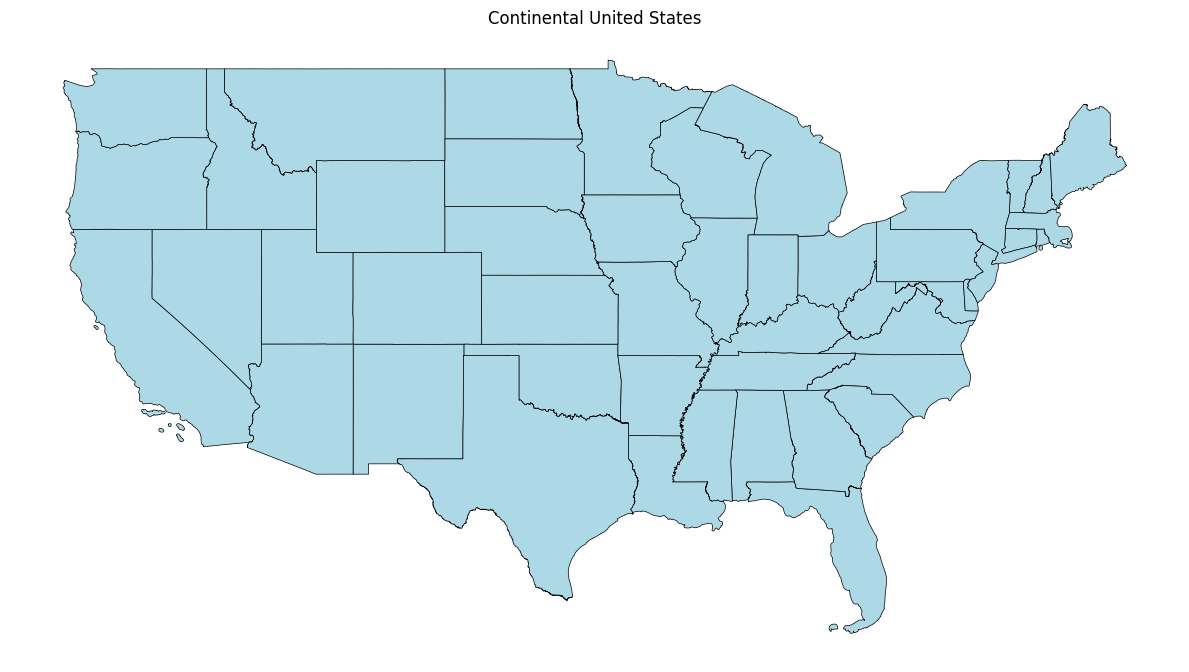

In [9]:
# Quick visualization of continental US
continental = states_gdf[
    ~states_gdf['statefp'].isin(['02', '15', '72', '78', '60', '66', '69'])
]

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
continental.plot(ax=ax, edgecolor='black', facecolor='lightblue', linewidth=0.5)
ax.set_title('Continental United States')
ax.axis('off')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'continental_us.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

### 3.2 County Boundaries (State-specific)

In [10]:
# Download county boundaries for California
ca_counties = get_census_boundaries(
    year=2020,
    geographic_level='county',
    state_fips='06'  # California
)

# Filter to just CA counties (national file includes all)
ca_counties = ca_counties[ca_counties['statefp'] == '06']

su.log_info(f"California has {len(ca_counties)} counties")
su.log_info("Sample counties:")
su.log_info(str(ca_counties[['name', 'geoid', 'aland']].head(10)))

[siege_utilities] 2026-02-21 18:37:36,338 INFO: Initialized Census data source with 23 available years


[siege_utilities] 2026-02-21 18:37:36,508 INFO: Constructed URL: https://www2.census.gov/geo/tiger/TIGER2020/COUNTY/tl_2020_us_county.zip


[siege_utilities] 2026-02-21 18:37:36,671 INFO: Downloading county boundaries for year 2020


[siege_utilities] 2026-02-21 18:37:36,672 INFO: Downloading TIGER/Line data from: https://www2.census.gov/geo/tiger/TIGER2020/COUNTY/tl_2020_us_county.zip


[siege_utilities] 2026-02-21 18:37:36,674 INFO: Ensured path exists: /home/dheerajchand/Downloads/siege_utilities


...

[siege_utilities] 2026-02-21 18:37:38,912 INFO: Successfully processed county boundaries: 3234 features


[siege_utilities] 2026-02-21 18:37:38,917 INFO: Filtered county from 3234 to 58 features for state 06


[siege_utilities] 2026-02-21 18:37:38,918 INFO: California has 58 counties


[siege_utilities] 2026-02-21 18:37:38,918 INFO: Sample counties:


[siege_utilities] 2026-02-21 18:37:38,922 INFO:               name  geoid        aland
8           Sierra  06091   2468694582
325     Sacramento  06067   2500040418
329  Santa Barbara  06083   7080860393
346      Calaveras  06009   2641837359
394        Ventura  06111   4767622152
397    Los Angeles  06037  10513491099
455         Sonoma  06097   4080862341
538          Kings  06031   3602601923
539      San Diego  06073  10904455257
552         Placer  06061   3644306224


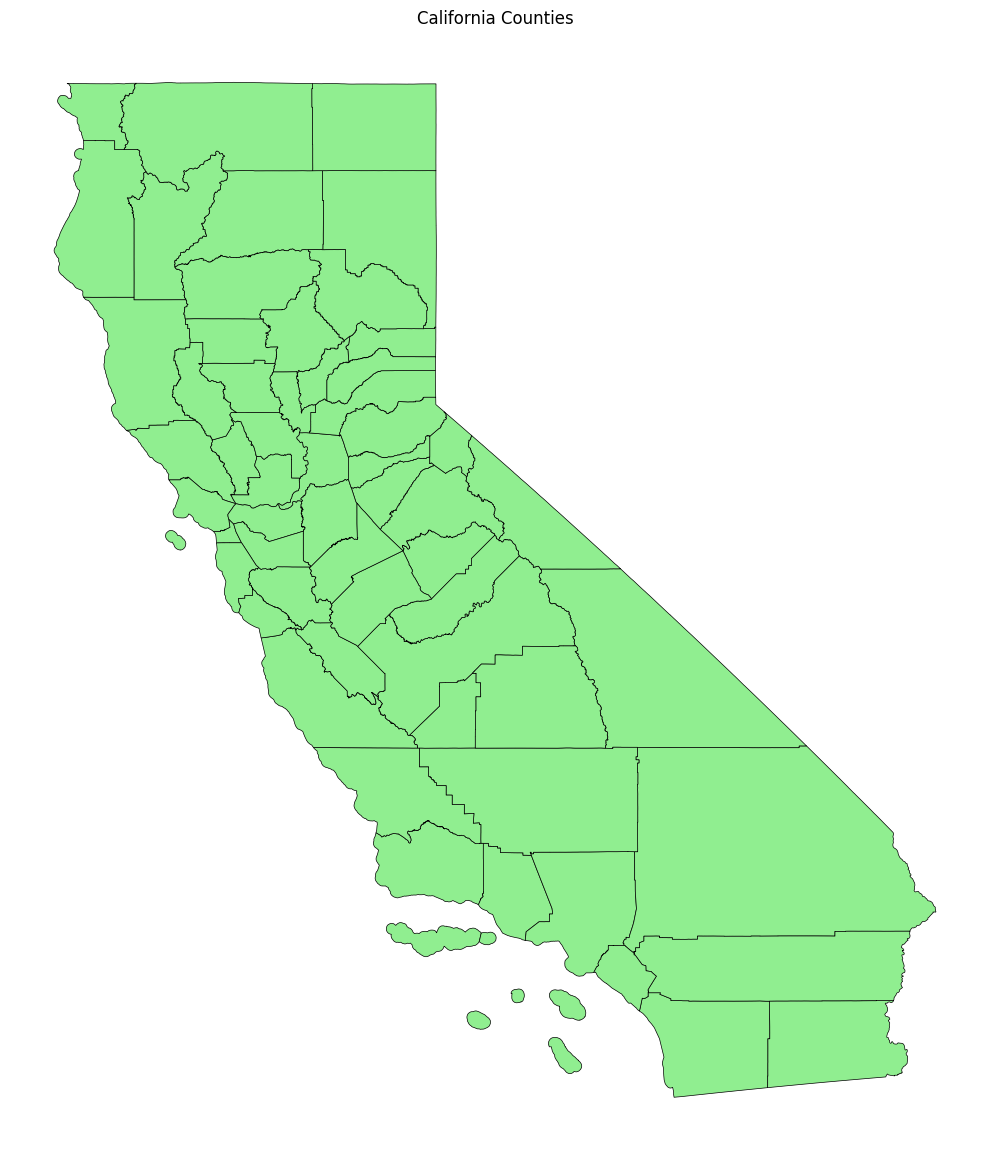

In [11]:
# Visualize California counties
fig, ax = plt.subplots(1, 1, figsize=(10, 12))
ca_counties.plot(ax=ax, edgecolor='black', facecolor='lightgreen', linewidth=0.5)
ax.set_title('California Counties')
ax.axis('off')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'california_counties.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

### 3.3 Census Tracts (County-specific)

In [12]:
# Download census tracts for Los Angeles County
la_tracts = get_census_boundaries(
    year=2020,
    geographic_level='tract',
    state_fips='06'  # California
)

# Filter to LA County (FIPS 037)
la_tracts = la_tracts[la_tracts['countyfp'] == '037']

su.log_info(f"Los Angeles County has {len(la_tracts)} census tracts")
su.log_info(f"Geoid format: {la_tracts['geoid'].iloc[0]}")

[siege_utilities] 2026-02-21 18:37:39,650 INFO: Initialized Census data source with 23 available years


[siege_utilities] 2026-02-21 18:37:39,651 INFO: Normalized '06' to FIPS 06: California (CA)


[siege_utilities] 2026-02-21 18:37:39,834 INFO: Constructing URL for California (CA)


[siege_utilities] 2026-02-21 18:37:39,835 INFO: Constructed URL: https://www2.census.gov/geo/tiger/TIGER2020/TRACT/tl_2020_06_tract.zip


[siege_utilities] 2026-02-21 18:37:39,971 INFO: Downloading tract boundaries for year 2020


...

[siege_utilities] 2026-02-21 18:37:40,594 INFO: Successfully downloaded https://www2.census.gov/geo/tiger/TIGER2020/TRACT/tl_2020_06_tract.zip to /home/dheerajchand/Downloads/siege_utilities/tl_2020_06_tract.zip


[siege_utilities] 2026-02-21 18:37:40,853 INFO: Extracted /home/dheerajchand/Downloads/siege_utilities/tl_2020_06_tract.zip to /home/dheerajchand/Downloads/siege_utilities/tl_2020_06_tract


[siege_utilities] 2026-02-21 18:37:41,077 INFO: Successfully processed tract boundaries: 9129 features


[siege_utilities] 2026-02-21 18:37:41,084 INFO: Los Angeles County has 2498 census tracts


[siege_utilities] 2026-02-21 18:37:41,084 INFO: Geoid format: 06037262601


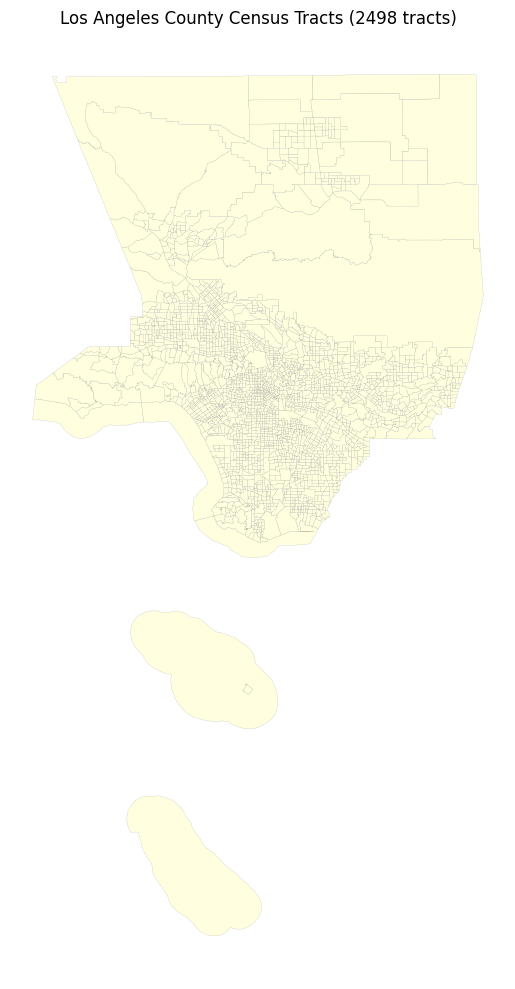

In [13]:
# Visualize LA County tracts
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
la_tracts.plot(ax=ax, edgecolor='gray', facecolor='lightyellow', linewidth=0.1)
ax.set_title(f'Los Angeles County Census Tracts ({len(la_tracts)} tracts)')
ax.axis('off')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'la_county_tracts.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

## 4. Working with Geographic Data

### 4.1 Calculate Areas

In [14]:
# Calculate area in square miles from ALAND (land area in sq meters)
ca_counties['area_sq_mi'] = ca_counties['aland'] / 2_589_988  # sq meters to sq miles

su.log_info("Largest California counties by area:")
su.log_info(str(ca_counties.nlargest(5, 'area_sq_mi')[['name', 'area_sq_mi']]))

su.log_info("Smallest California counties by area:")
su.log_info(str(ca_counties.nsmallest(5, 'area_sq_mi')[['name', 'area_sq_mi']]))

[siege_utilities] 2026-02-21 18:37:41,905 INFO: Largest California counties by area:


[siege_utilities] 2026-02-21 18:37:41,909 INFO:                 name    area_sq_mi
1110  San Bernardino  20068.011481
981             Inyo  10197.260780
1631            Kern   8134.645504
1622       Riverside   7209.269373
2978        Siskiyou   6278.767790


[siege_utilities] 2026-02-21 18:37:41,910 INFO: Smallest California counties by area:


[siege_utilities] 2026-02-21 18:37:41,912 INFO:                name  area_sq_mi
636   San Francisco   46.914151
3025     Santa Cruz  445.107693
2880      San Mateo  448.620625
675           Marin  520.423186
2722         Amador  594.584136


### 4.2 Spatial Joins

In [15]:
# Create sample point data (cities in CA)
from shapely.geometry import Point

cities = gpd.GeoDataFrame({
    'city': ['Los Angeles', 'San Francisco', 'San Diego', 'Sacramento', 'Fresno'],
    'geometry': [
        Point(-118.2437, 34.0522),
        Point(-122.4194, 37.7749),
        Point(-117.1611, 32.7157),
        Point(-121.4944, 38.5816),
        Point(-119.7871, 36.7378)
    ]
}, crs='EPSG:4326')

# Spatial join to find which county each city is in
cities_with_county = gpd.sjoin(cities, ca_counties[['name', 'geometry']], how='left', predicate='within')
cities_with_county = cities_with_county.rename(columns={'name': 'county'})

su.log_info("Cities with their counties:")
su.log_info(str(cities_with_county[['city', 'county']]))

[siege_utilities] 2026-02-21 18:37:41,925 INFO: Cities with their counties:


[siege_utilities] 2026-02-21 18:37:41,927 INFO:             city         county
0    Los Angeles    Los Angeles
1  San Francisco  San Francisco
2      San Diego      San Diego
3     Sacramento     Sacramento
4         Fresno         Fresno


## 5. Alternative Download Function

The `download_data()` function provides a simpler interface.

In [16]:
# Using download_data() - equivalent functionality
tx_counties = download_data(
    year=2020,
    geographic_level='county',
    state_fips='48'  # Texas
)

tx_counties = tx_counties[tx_counties['statefp'] == '48']
su.log_info(f"Texas has {len(tx_counties)} counties")

[siege_utilities] 2026-02-21 18:37:41,933 INFO: Normalized '48' to FIPS 48: Texas (TX)


[siege_utilities] 2026-02-21 18:37:41,934 INFO: Constructing URL for Texas (TX)


[siege_utilities] 2026-02-21 18:37:41,934 INFO: Constructed URL: https://www2.census.gov/geo/tiger/TIGER2020/COUNTY/tl_2020_us_county.zip


[siege_utilities] 2026-02-21 18:37:42,066 INFO: Downloading county boundaries for year 2020


[siege_utilities] 2026-02-21 18:37:42,067 INFO: Downloading TIGER/Line data from: https://www2.census.gov/geo/tiger/TIGER2020/COUNTY/tl_2020_us_county.zip


...

tl_2020_us_county.zip: 100%|##########| 80.6M/80.6M [00:01<00:00, 76.9MB/s]

[siege_utilities] 2026-02-21 18:37:43,524 INFO: Successfully downloaded https://www2.census.gov/geo/tiger/TIGER2020/COUNTY/tl_2020_us_county.zip to /home/dheerajchand/Downloads/siege_utilities/tl_2020_us_county.zip


[siege_utilities] 2026-02-21 18:37:44,177 INFO: Extracted /home/dheerajchand/Downloads/siege_utilities/tl_2020_us_county.zip to /home/dheerajchand/Downloads/siege_utilities/tl_2020_us_county


[siege_utilities] 2026-02-21 18:37:44,513 INFO: Successfully processed county boundaries: 3234 features


[siege_utilities] 2026-02-21 18:37:44,518 INFO: Texas has 254 counties


## Summary (Part 1: Boundaries)

This section demonstrated:

| Function | Purpose |
|----------|----------|
| `normalize_state_identifier()` | Convert any state format to FIPS |
| `get_available_years()` | List available Census years |
| `discover_boundary_types()` | Find boundary types for a year |
| `get_census_boundaries()` | Download TIGER/Line shapefiles |
| `download_data()` | Simplified download interface |

**Key Parameters:**
- `year`: Census year (1992-present)
- `geographic_level`: state, county, tract, bg (block group), place, zcta, cd
- `state_fips`: Required for tract, bg, block levels

---

## Part 2: Census Demographics (CensusAPIClient)

The `CensusAPIClient` fetches demographic data from the Census Bureau API (ACS, Decennial).
It complements boundary downloads by providing actual demographic values.

In [17]:
# Import CensusAPIClient
import os
from siege_utilities.geo.census_api_client import (
    CensusAPIClient,
    get_demographics,
    get_population,
    get_income_data,
    get_census_data_with_geometry,
    VARIABLE_GROUPS
)

# Show available variable groups
su.log_info("Available predefined variable groups:")
for group_name, variables in VARIABLE_GROUPS.items():
    su.log_info(f"  {group_name}: {len(variables)} variables")

[siege_utilities] 2026-02-21 18:37:44,524 INFO: Available predefined variable groups:


[siege_utilities] 2026-02-21 18:37:44,525 INFO:   total_population: 1 variables


[siege_utilities] 2026-02-21 18:37:44,525 INFO:   demographics_basic: 4 variables


[siege_utilities] 2026-02-21 18:37:44,526 INFO:   race_ethnicity: 9 variables


[siege_utilities] 2026-02-21 18:37:44,527 INFO:   income: 3 variables


...

[siege_utilities] 2026-02-21 18:37:44,530 INFO:   pl_p4_hispanic_18plus: 11 variables


[siege_utilities] 2026-02-21 18:37:44,531 INFO:   pl_p5_group_quarters: 10 variables


[siege_utilities] 2026-02-21 18:37:44,531 INFO:   pl_h1_housing: 3 variables


[siege_utilities] 2026-02-21 18:37:44,531 INFO:   pl_redistricting_core: 18 variables


[siege_utilities] 2026-02-21 18:37:44,532 INFO:   pl_voting_age: 10 variables


### Quick Demographic Fetch (Convenience Functions)

These functions work without an API key for basic queries (rate-limited).

In [18]:
# Get population data for California counties (2022 ACS 5-year)
# Note: API key optional but recommended for higher rate limits
# Set CENSUS_API_KEY environment variable or pass api_key parameter

try:
    ca_pop = get_population(
        state='California',
        geography='county',
        year=2022
    )
    su.log_info(f"Retrieved population for {len(ca_pop)} California counties")
    su.log_info("Top 5 most populous counties:")
    su.log_info(str(ca_pop.nlargest(5, 'B01001_001E')[['NAME', 'B01001_001E']]))
except Exception as e:
    su.log_warning(f"Note: Census API may require an API key. Error: {e}")
    su.log_info("Get a free key at: https://api.census.gov/data/key_signup.html")

[siege_utilities] 2026-02-21 18:37:44,540 INFO: Initialized CensusAPIClient (API key: not set)


[siege_utilities] 2026-02-21 18:37:44,555 INFO: Returning cached data for county (58 rows)


[siege_utilities] 2026-02-21 18:37:44,556 INFO: Retrieved population for 58 California counties


[siege_utilities] 2026-02-21 18:37:44,557 INFO: Top 5 most populous counties:


[siege_utilities] 2026-02-21 18:37:44,559 INFO:                                  NAME  B01001_001E
18     Los Angeles County, California      9936690
36       San Diego County, California      3289701
29          Orange County, California      3175227
32       Riverside County, California      2429487
35  San Bernardino County, California      2180563


### Combined Geometry + Demographics

The most powerful function: download boundaries AND demographics in one call.

In [19]:
# Get California counties with income data - geometry + demographics in one GeoDataFrame
try:
    ca_income_gdf = get_census_data_with_geometry(
        year=2022,
        geography='county',
        state_fips='06',  # California
        variables=['B19013_001E']  # Median household income
    )
    
    su.log_info(f"GeoDataFrame with {len(ca_income_gdf)} counties")
    su.log_info(f"Columns: {list(ca_income_gdf.columns)}")
    
    # Create a choropleth map of median income
    fig, ax = plt.subplots(1, 1, figsize=(10, 12))
    ca_income_gdf.plot(
        column='B19013_001E',
        ax=ax,
        legend=True,
        legend_kwds={'label': 'Median Household Income ($)'},
        cmap='YlGnBu',
        edgecolor='black',
        linewidth=0.3
    )
    ax.set_title('California Counties - Median Household Income (2022 ACS)')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'ca_income_choropleth.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    
except Exception as e:
    su.log_warning(f"Note: Requires Census API. Error: {e}")

[siege_utilities] 2026-02-21 18:37:44,567 WARNING: Note: Requires Census API. Error: get_census_data_with_geometry() got an unexpected keyword argument 'state_fips'


### GEOID Utilities

GEOIDs are standardized identifiers for Census geographies. These utilities help with normalization and joining.

In [20]:
from siege_utilities.geo.geoid_utils import (
    construct_geoid,
    parse_geoid,
    normalize_geoid,
    validate_geoid,
    can_normalize_geoid,
    GEOID_LENGTHS
)

# GEOID lengths by geography type
su.log_info("GEOID lengths by geography:")
for geo, length in GEOID_LENGTHS.items():
    su.log_info(f"  {geo}: {length} digits")

su.log_info("=" * 50)

# Construct GEOIDs from components
tract_geoid = construct_geoid(
    geography='tract',
    state='06',      # California
    county='037',    # Los Angeles
    tract='207400'   # Tract number
)
su.log_info(f"Constructed tract GEOID: {tract_geoid}")

# Parse a GEOID back to components
components = parse_geoid(tract_geoid, 'tract')
su.log_info(f"Parsed components: {components}")

# Normalize incomplete GEOIDs (adds leading zeros)
su.log_info(f"Normalize '6037' as county: {normalize_geoid('6037', 'county')}")
su.log_info(f"Normalize '6' as state: {normalize_geoid('6', 'state')}")

# Validate GEOIDs — strict by default (requires proper zero-padding)
su.log_info(f"Is '06037' a valid county GEOID? {validate_geoid('06037', 'county')}")
su.log_info(f"Is '6037' a valid county GEOID? {validate_geoid('6037', 'county')}")

# Check normalizability — can a value be zero-padded to a valid GEOID?
su.log_info(f"Can '6037' be normalized to a county GEOID? {can_normalize_geoid('6037', 'county')}")
su.log_info(f"Can 'CA037' be normalized to a county GEOID? {can_normalize_geoid('CA037', 'county')}")

[siege_utilities] 2026-02-21 18:37:44,575 INFO: GEOID lengths by geography:


[siege_utilities] 2026-02-21 18:37:44,576 INFO:   nation: 1 digits


[siege_utilities] 2026-02-21 18:37:44,577 INFO:   region: 1 digits


[siege_utilities] 2026-02-21 18:37:44,577 INFO:   division: 1 digits


[siege_utilities] 2026-02-21 18:37:44,577 INFO:   state: 2 digits


...

[siege_utilities] 2026-02-21 18:37:44,588 INFO: Normalize '6' as state: 06


[siege_utilities] 2026-02-21 18:37:44,591 INFO: Is '06037' a valid county GEOID? True


[siege_utilities] 2026-02-21 18:37:44,591 INFO: Is '6037' a valid county GEOID? False


[siege_utilities] 2026-02-21 18:37:44,592 INFO: Can '6037' be normalized to a county GEOID? True


[siege_utilities] 2026-02-21 18:37:44,592 INFO: Can 'CA037' be normalized to a county GEOID? False


## Part 4: Intelligent Dataset Selection

The `CensusDataSelector` helps you choose the right Census dataset for your analysis.
Given an analysis type, geography level, and time period, it recommends which datasets
to use and checks compatibility.

In [21]:
from siege_utilities.geo.census_data_selector import (
    CensusDataSelector,
    select_datasets_for_analysis,
    get_dataset_compatibility_matrix,
    suggest_analysis_approach,
)

# Initialize selector
selector = CensusDataSelector()

# Example 1: What datasets work for poverty analysis at tract level?
result = select_datasets_for_analysis(
    analysis_type='poverty',
    geography_level='tract',
    time_period='2015-2022'
)
su.log_info("Dataset selection for poverty analysis at tract level:")
for key, val in result.items():
    su.log_info(f"  {key}: {val}")

# Example 2: Compatibility matrix
matrix = get_dataset_compatibility_matrix()
su.log_info(f"Compatibility matrix shape: {matrix.shape}")
display(matrix)

# Example 3: Suggest an approach
approach = suggest_analysis_approach(
    analysis_type='demographics',
    geography_level='county',
    time_constraints='standard'
)
su.log_info("Suggested approach:")
for key, val in approach.items():
    su.log_info(f"  {key}: {val}")

[siege_utilities] 2026-02-21 18:37:44,601 INFO: Dataset selection for poverty analysis at tract level:


[siege_utilities] 2026-02-21 18:37:44,602 INFO:   analysis_type: poverty


[siege_utilities] 2026-02-21 18:37:44,603 INFO:   geography_level: tract


[siege_utilities] 2026-02-21 18:37:44,603 INFO:   primary_recommendation: {'dataset': 'ACS 5-Year Estimates (2020)', 'survey_type': 'acs_5yr', 'time_period': '2016-2020', 'reliability': 'medium', 'suitability_score': 3.0, 'score_breakdown': {'geography_match': 2.0, 'primary_dataset': 0.0, 'reliability_match': 1.0, 'time_period': 0.0, 'variable_coverage': 0.0, 'geography_preference': 0.0, 'total': 3.0}, 'rationale': 'Meets reliability requirements; Provides detailed geographic coverage; 5-year estimates provide stable data for small areas', 'variables': ['income', 'education', 'employment', 'housing_value', 'rent', 'commute_time', 'health_insurance', 'poverty_status'], 'limitations': ['5-year period may mask recent changes', 'Smaller geographies have higher margins of error', 'Not suitable for very recent analysis'], 'api_endpoint': 'https://api.census.gov/data/2020/acs/acs5'}


[siege_utilities] 2026-02-21 18:37:44,604 INFO:   alternatives: []


...

[siege_utilities] 2026-02-21 18:37:44,620 INFO:   recommended_approach: Use 5-year ACS estimates for stable, detailed analysis


[siege_utilities] 2026-02-21 18:37:44,620 INFO:   data_sources: {'dataset': 'ACS 5-Year Estimates (2020)', 'survey_type': 'acs_5yr', 'time_period': '2016-2020', 'reliability': 'medium', 'suitability_score': 3.0, 'score_breakdown': {'geography_match': 2.0, 'primary_dataset': 0.0, 'reliability_match': 1.0, 'time_period': 0.0, 'variable_coverage': 0.0, 'geography_preference': 0.0, 'total': 3.0}, 'rationale': 'Meets reliability requirements; Provides detailed geographic coverage; 5-year estimates provide stable data for small areas', 'variables': ['income', 'education', 'employment', 'housing_value', 'rent', 'commute_time', 'health_insurance', 'poverty_status'], 'limitations': ['5-year period may mask recent changes', 'Smaller geographies have higher margins of error', 'Not suitable for very recent analysis'], 'api_endpoint': 'https://api.census.gov/data/2020/acs/acs5'}


[siege_utilities] 2026-02-21 18:37:44,621 INFO:   methodology_notes: ['5-year estimates represent average conditions over 2016-2020', 'Check margins of error for small geographies', 'Consider statistical significance when comparing areas', 'Data reliability: medium', 'Last updated: Unknown']


[siege_utilities] 2026-02-21 18:37:44,622 INFO:   quality_checks: ['Verify geography boundaries match your analysis area', 'Check for missing or suppressed data', 'Review margins of error for small geographies', 'Compare with known benchmarks or previous data', 'Validate against other data sources if available', 'Review ACS data quality flags and notes']


[siege_utilities] 2026-02-21 18:37:44,623 INFO:   reporting_considerations: ['Clearly state the data source and time period', 'Include reliability information in your report', 'Note any limitations or caveats', "Provide context for the data (e.g., '5-year average')", 'Consider margins of error in your conclusions']


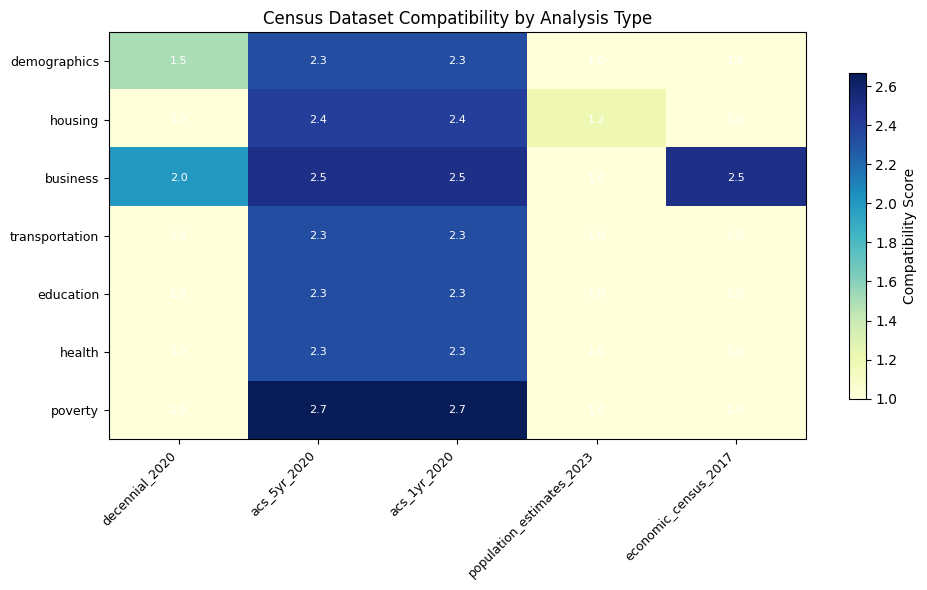

In [22]:
# Visualize the compatibility matrix as a heatmap
fig, ax = plt.subplots(figsize=(10, 6))
matrix_plot = matrix.set_index('analysis_type') if 'analysis_type' in matrix.columns else matrix
im = ax.imshow(matrix_plot.values, cmap='YlGnBu', aspect='auto')

ax.set_xticks(range(len(matrix_plot.columns)))
ax.set_xticklabels(matrix_plot.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(matrix_plot.index)))
ax.set_yticklabels(matrix_plot.index, fontsize=9)

# Add score values in each cell
for i in range(len(matrix_plot.index)):
    for j in range(len(matrix_plot.columns)):
        val = matrix_plot.iloc[i, j]
        color = 'white' if val > 0.6 else 'black'
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', color=color, fontsize=8)

plt.colorbar(im, ax=ax, label='Compatibility Score', shrink=0.8)
ax.set_title('Census Dataset Compatibility by Analysis Type')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'dataset_compatibility_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

## Part 5: Boundary Crosswalks

Census boundaries change between decennial censuses. Crosswalk files map geographies
from one vintage to another (e.g., 2010 tracts to 2020 tracts), enabling longitudinal analysis.

In [23]:
from siege_utilities.geo.crosswalk import (
    CrosswalkClient,
    get_crosswalk,
    get_crosswalk_metadata,
    list_available_crosswalks,
)
from siege_utilities.geo.crosswalk.relationship_types import (
    RelationshipType, WeightMethod, CrosswalkMetadata
)

# List what's available
available = list_available_crosswalks()
su.log_info(f"Available crosswalks: {len(available)}")
for cw in available:
    su.log_info(f"  {cw}")

# Get tract crosswalk metadata (2010 -> 2020)
try:
    meta = get_crosswalk_metadata(source_year=2010, target_year=2020, geography_level='tract')
    su.log_info(f"Tract crosswalk 2010->2020:")
    for key, val in meta.summary().items():
        su.log_info(f"  {key}: {val}")
except Exception as e:
    su.log_warning(f"Crosswalk metadata not available: {e}")
    su.log_info("This requires downloading Census crosswalk files")

[siege_utilities] 2026-02-21 18:37:45,238 INFO: Initialized CrosswalkClient (cache: /home/dheerajchand/.siege_utilities/cache/crosswalk)


[siege_utilities] 2026-02-21 18:37:45,239 INFO: Available crosswalks: 8


[siege_utilities] 2026-02-21 18:37:45,239 INFO:   {'source_year': 2010, 'target_year': 2020, 'geography_level': 'tract'}


[siege_utilities] 2026-02-21 18:37:45,239 INFO:   {'source_year': 2010, 'target_year': 2020, 'geography_level': 'block_group'}


[siege_utilities] 2026-02-21 18:37:45,240 INFO:   {'source_year': 2010, 'target_year': 2020, 'geography_level': 'block'}


...

[siege_utilities] 2026-02-21 18:37:45,576 INFO:   total_target_units: 85528


[siege_utilities] 2026-02-21 18:37:45,577 INFO:   unchanged: 41846


[siege_utilities] 2026-02-21 18:37:45,577 INFO:   splits: 32288


[siege_utilities] 2026-02-21 18:37:45,578 INFO:   merges: 28273


[siege_utilities] 2026-02-21 18:37:45,578 INFO:   change_rate: 81.7%


## Part 6: Time-Series Analysis

Analyze longitudinal Census data with change metrics and trend classification.
This section includes dual-mode cells (Pandas + optional Spark).

In [24]:
# Spark availability (for dual-mode cells)
SPARK_AVAILABLE = False
spark = None
try:
    from pyspark.sql import SparkSession
    from pyspark.sql import functions as F
    SPARK_AVAILABLE = True
    su.log_info("PySpark available for dual-mode cells")
except ImportError:
    su.log_info("PySpark not installed -- pandas-only mode")

[siege_utilities] 2026-02-21 18:37:45,585 INFO: PySpark available for dual-mode cells


In [25]:
import numpy as np

from siege_utilities.geo.timeseries.change_metrics import (
    calculate_change_metrics,
    calculate_index,
    get_change_summary,
)
from siege_utilities.geo.timeseries.trend_classifier import (
    classify_trends,
    TrendThresholds,
    TrendCategory,
    get_trend_summary,
    identify_outliers,
)

# Create sample longitudinal data
np.random.seed(42)
n_tracts = 50
longitudinal_df = pd.DataFrame({
    'GEOID': [f'0603700{i:04d}' for i in range(n_tracts)],
    'income_2010': np.random.normal(60000, 15000, n_tracts).astype(int),
    'income_2015': np.random.normal(65000, 16000, n_tracts).astype(int),
    'income_2020': np.random.normal(72000, 18000, n_tracts).astype(int),
})

su.log_info(f"Longitudinal data: {longitudinal_df.shape}")
display(longitudinal_df.head())

# Calculate change metrics between 2010 and 2020
longitudinal_df['pct_change'] = (
    (longitudinal_df['income_2020'] - longitudinal_df['income_2010']) / 
    longitudinal_df['income_2010'] * 100
)

# Classify trends
classified = classify_trends(
    longitudinal_df, 'pct_change',
    thresholds=TrendThresholds(rapid_growth=25, moderate_growth=10, stable_lower=-10, moderate_decline=-25)
)
su.log_info("Trend classification:")
su.log_info(str(classified['trend_category'].value_counts()))

# Identify outliers
outliers = identify_outliers(longitudinal_df, 'pct_change', method='iqr')
n_outliers = outliers['is_outlier'].sum()
su.log_info(f"Outliers detected: {n_outliers} of {len(outliers)}")

# Summary
summary = get_trend_summary(classified, trend_column='trend_category')
su.log_info("Trend summary:")
for key, val in summary.items():
    su.log_info(f"  {key}: {val}")

[siege_utilities] 2026-02-21 18:37:45,594 INFO: Longitudinal data: (50, 4)


,GEOID,income_2010,income_2015,income_2020
0,06037000000,67450,70185,46523
1,06037000001,57926,58838,64428
2,06037000002,69715,54169,65831
3,06037000003,82845,74786,57559
4,06037000004,56487,81495,69096


[siege_utilities] 2026-02-21 18:37:45,599 INFO: Classifying trends in 'pct_change' using thresholds: {'rapid_growth': '>= 25%', 'moderate_growth': '10% to 25%', 'stable': '-10% to 10%', 'moderate_decline': '-25% to -10%', 'rapid_decline': '< -25%'}


[siege_utilities] 2026-02-21 18:37:45,601 INFO: Trend distribution:
trend_category
rapid_growth        24
stable               9
moderate_growth      6
moderate_decline     6
rapid_decline        5


[siege_utilities] 2026-02-21 18:37:45,601 INFO: Trend classification:


...

[siege_utilities] 2026-02-21 18:37:45,605 INFO: Outliers detected: 1 of 50


[siege_utilities] 2026-02-21 18:37:45,607 INFO: Trend summary:


[siege_utilities] 2026-02-21 18:37:45,607 INFO:   total_geographies: 50


[siege_utilities] 2026-02-21 18:37:45,608 INFO:   categories: {'rapid_growth': {'count': 24, 'percentage': np.float64(48.0)}, 'stable': {'count': 9, 'percentage': np.float64(18.0)}, 'moderate_growth': {'count': 6, 'percentage': np.float64(12.0)}, 'moderate_decline': {'count': 6, 'percentage': np.float64(12.0)}, 'rapid_decline': {'count': 5, 'percentage': np.float64(10.0)}}


[siege_utilities] 2026-02-21 18:37:45,609 INFO:   overview: {'growing': 30, 'declining': 11, 'stable': 9, 'growth_to_decline_ratio': 2.73}


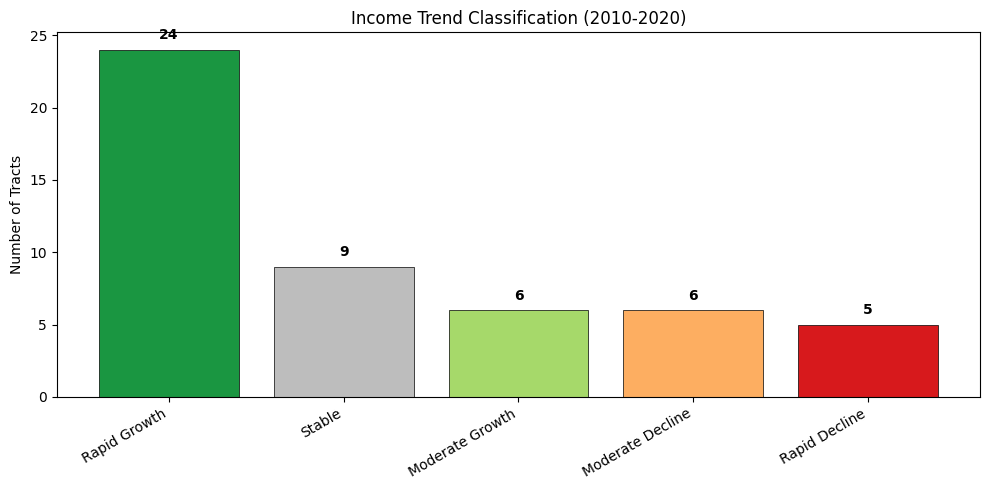

In [26]:
# Trend category distribution
trend_counts = classified['trend_category'].value_counts()

# Color-code by trend direction
trend_colors = {
    'rapid_growth': '#1a9641',
    'moderate_growth': '#a6d96a',
    'stable': '#bdbdbd',
    'moderate_decline': '#fdae61',
    'rapid_decline': '#d7191c',
}
colors = [trend_colors.get(str(cat), '#999999') for cat in trend_counts.index]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(trend_counts)), trend_counts.values, color=colors, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(trend_counts)))
ax.set_xticklabels([str(c).replace('_', ' ').title() for c in trend_counts.index], rotation=30, ha='right')
ax.set_ylabel('Number of Tracts')
ax.set_title('Income Trend Classification (2010-2020)')

# Add count labels on bars
for bar, count in zip(bars, trend_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, str(count),
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'trend_categories.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

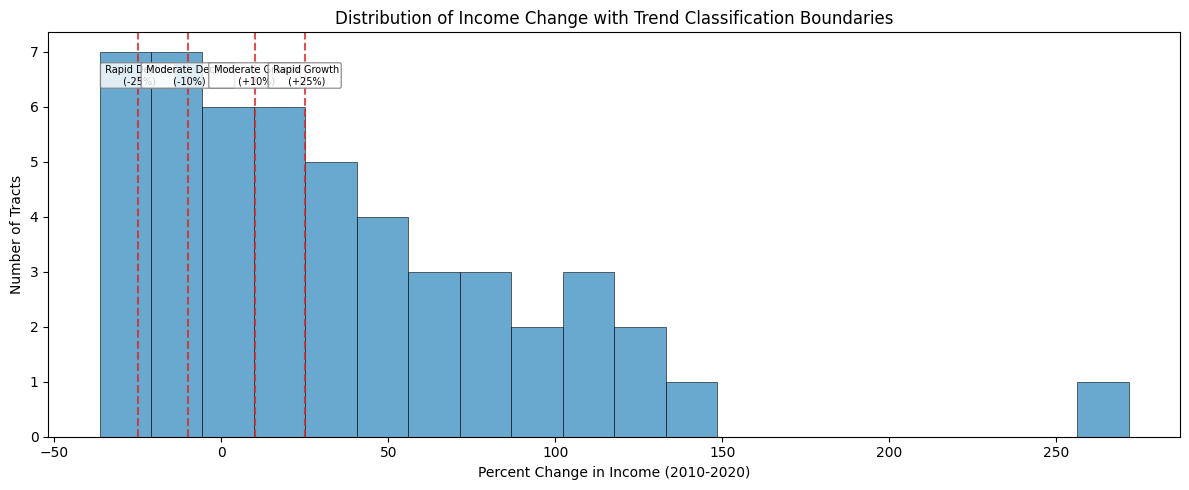

In [27]:
# Percent change distribution with trend threshold boundaries
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(longitudinal_df['pct_change'], bins=20, color='#4393c3', edgecolor='black', linewidth=0.5, alpha=0.8)

# Draw threshold boundaries
thresholds = {'Rapid Decline': -25, 'Moderate Decline': -10, 'Moderate Growth': 10, 'Rapid Growth': 25}
for label, val in thresholds.items():
    ax.axvline(val, color='#d62728', linestyle='--', linewidth=1.5, alpha=0.8)
    ax.text(val, ax.get_ylim()[1] * 0.92, f' {label}\n ({val:+d}%)',
            fontsize=7, rotation=0, va='top', ha='center',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='gray'))

ax.set_xlabel('Percent Change in Income (2010-2020)')
ax.set_ylabel('Number of Tracts')
ax.set_title('Distribution of Income Change with Trend Classification Boundaries')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pct_change_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

In [28]:
# Dual-mode: trend aggregation
# Pandas (always runs)
pdf_trend_agg = classified.groupby('trend_category').agg(
    count=('GEOID', 'count'),
    avg_change=('pct_change', 'mean')
).reset_index()
su.log_info("Pandas -- Trend aggregation:")
display(pdf_trend_agg)

# Spark (conditional)
if SPARK_AVAILABLE and spark:
    sdf = spark.createDataFrame(classified[['GEOID', 'pct_change', 'trend_category']])
    sdf_agg = sdf.groupBy('trend_category').agg(
        F.count('GEOID').alias('count'),
        F.avg('pct_change').alias('avg_change')
    )
    su.log_info("Spark -- Trend aggregation:")
    sdf_agg.show()

[siege_utilities] 2026-02-21 18:37:46,120 INFO: Pandas -- Trend aggregation:


,trend_category,count,avg_change
0,moderate_decline,6,-17.845045
1,moderate_growth,6,17.924429
2,rapid_decline,5,-30.686866
3,rapid_growth,24,82.106763
4,stable,9,-0.746724


## Complete Summary

### Part 1: Boundary Downloads

| Function | Purpose |
|----------|--------|
| `get_census_boundaries()` | Download TIGER/Line shapefiles |
| `normalize_state_identifier()` | Convert state names/abbrevs to FIPS |
| `get_available_years()` | List available Census years |
| `discover_boundary_types()` | Find boundary types for a year |

### Part 2: Demographics (CensusAPIClient)

| Function | Purpose |
|----------|--------|
| `get_population()` | Fetch population counts |
| `get_demographics()` | Fetch demographic variables |
| `get_income_data()` | Fetch income-related variables |
| `get_census_data_with_geometry()` | Combined: boundaries + demographics in one GeoDataFrame |

### Part 3: GEOID Utilities

| Function | Purpose |
|----------|--------|
| `construct_geoid()` | Build GEOID from components |
| `parse_geoid()` | Extract components from GEOID |
| `normalize_geoid()` | Add leading zeros |
| `validate_geoid()` | Check GEOID format (strict -- requires leading zeros) |
| `can_normalize_geoid()` | Check if a value can be zero-padded to a valid GEOID |

### Part 4: Intelligent Dataset Selection

| Function | Purpose |
|----------|--------|
| `CensusDataSelector()` | Initialize dataset selector |
| `select_datasets_for_analysis()` | Recommend datasets for an analysis type/geography/time period |
| `get_dataset_compatibility_matrix()` | Show which datasets support which geographies |
| `suggest_analysis_approach()` | Get a recommended approach for your analysis |

### Part 5: Boundary Crosswalks

| Function | Purpose |
|----------|--------|
| `list_available_crosswalks()` | List available crosswalk files |
| `get_crosswalk()` | Download a crosswalk table |
| `get_crosswalk_metadata()` | Get metadata about a crosswalk |
| `CrosswalkClient` | Full client for crosswalk operations |

### Part 6: Time-Series Analysis

| Function | Purpose |
|----------|--------|
| `classify_trends()` | Classify percent-change values into trend categories |
| `TrendThresholds` | Configure thresholds for trend classification |
| `identify_outliers()` | Detect outliers using IQR or z-score methods |
| `get_trend_summary()` | Summarize trend classification results |
| `calculate_change_metrics()` | Compute change metrics across time periods |

**API Key**: Get a free Census API key at https://api.census.gov/data/key_signup.html
Set as `CENSUS_API_KEY` environment variable or pass `api_key` parameter.